In [40]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [24]:
from data_load import scaled_data, raw_data, result, data_info

In [25]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [26]:
# Thickness는 모두 같은 값이므로 예측에 영향 X

print(np.sum(raw_data['Thickness 1(mm)'] != 0.7))
print(np.sum(raw_data['Thickness 2(mm)'] != 0.7))

0
0


In [27]:
# 쓸모없는 열 제외 
raw_data_clean = raw_data.iloc[:, 6:]

split = 8470

# train, test 셋 구분
train_data = raw_data_clean.iloc[:split]
test_data = raw_data_clean.iloc[split:]

print(f'Data_columns : {train_data.columns}')
print(f'Train data : {len(train_data)}, Test data : {len(test_data)}')

Data_columns : Index(['weld force(bar)', 'weld current(kA)', 'weld Voltage(v)',
       'weld time(ms)'],
      dtype='str')
Train data : 8470, Test data : 3469


In [28]:
# 군집화 결과 비교
split = result['working time'].searchsorted(pd.Timestamp('2020-04-02'))

undercut_train_idx = result.iloc[:split]['defect type'] == 1
lack_train_idx = result.iloc[:split]['defect type'] == 2
crack_train_idx = result.iloc[:split]['defect type'] == 3

undercut_test_idx = result.iloc[split:]['defect type'] == 1
lack_test_idx = result.iloc[split:]['defect type'] == 2
crack_test_idx = result.iloc[split:]['defect type'] == 3

defect_train = pd.Series(result.iloc[:split]['defect'], dtype=int)
defect_test = pd.Series(result.iloc[split:]['defect'], dtype=int)
print(f'훈련 데이터 이상치 갯수 \n'
      f'파임불량 : {np.sum(defect_train[undercut_train_idx])}\n'
      f'용접부족 : {np.sum(defect_train[crack_train_idx])}\n'
      f'크랙발생 : {np.sum(defect_train[lack_train_idx])}\n'
      f'총 결함 수 : {np.sum(defect_train[undercut_train_idx]) + np.sum(defect_train[crack_train_idx]) + np.sum(defect_train[lack_train_idx])}\n')

print(f'테스트 데이터 이상치 갯수 \n'
      f'파임불량 : {np.sum(defect_test[undercut_test_idx])}\n'
      f'용접부족 : {np.sum(defect_test[crack_test_idx])}\n'
      f'크랙발생 : {np.sum(defect_test[lack_test_idx])}\n'
      f'총 결함 수 : {np.sum(defect_test[undercut_test_idx]) + np.sum(defect_test[crack_test_idx]) + np.sum(defect_test[lack_test_idx])}')

훈련 데이터 이상치 갯수 
파임불량 : 11
용접부족 : 7
크랙발생 : 10
총 결함 수 : 28

테스트 데이터 이상치 갯수 
파임불량 : 3
용접부족 : 5
크랙발생 : 3
총 결함 수 : 11


In [29]:
defect = result 

In [30]:
# 데이터 정규화

scaler = RobustScaler()

train_scaled = scaler.fit_transform(train_data).astype(np.float32)
test_scaled = scaler.transform(test_data).astype(np.float32)

train_scaled = pd.DataFrame(
    train_scaled,
    columns=train_data.columns,
    index=train_data.index
)

test_scaled = pd.DataFrame(
    test_scaled,
    columns=test_data.columns,
    index=test_data.index
)

train_scaled.head(3)

train_tensor = torch.tensor(train_scaled.to_numpy(), dtype=torch.float32)
test_tensor = torch.tensor(test_scaled.to_numpy(), dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_tensor),
    batch_size=64,
    shuffle=False
)

In [31]:
# 신경망 작성

class AutoEncoder(nn.Module):

    def __init__(self, input_size, latent_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.latent_size = latent_size
        self.hidden_size = hidden_size

        self.fc1 = nn.Linear(self.input_size, self.hidden_size[0])
        self.fc2 = nn.Linear(self.hidden_size[0], self.hidden_size[1])
        self.fc3 = nn.Linear(self.hidden_size[1], self.latent_size)

        self.fc4 = nn.Linear(self.latent_size, self.hidden_size[1])
        self.fc5 = nn.Linear(self.hidden_size[1], self.hidden_size[0])
        self.fc6 = nn.Linear(self.hidden_size[0], self.input_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        return self.fc6(x)

In [52]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

input_size = train_tensor.shape[1]
latent_size = 2
hidden_size = (8, 4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
autoencoder = AutoEncoder(input_size, latent_size, hidden_size).to(device)
optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def train(model, data_loader, optimizer, criterion, epochs=120):
    model.train()
    history = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for (features,) in data_loader:
            features = features.to(device)

            optimizer.zero_grad()
            reconstructed = model(features)
            batch_loss = criterion(reconstructed, features)
            batch_loss.backward()
            optimizer.step()

            epoch_loss += batch_loss.item() * features.size(0)

        epoch_loss /= len(data_loader.dataset)
        history.append(epoch_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch + 1:3d}/{epochs}, loss: {epoch_loss:.6f}')

    return history


def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for (features,) in data_loader:
            features = features.to(device)
            reconstructed = model(features)
            batch_loss = criterion(reconstructed, features)
            total_loss += batch_loss.item() * features.size(0)

    return total_loss / len(data_loader.dataset)

loss_history = train(autoencoder, train_loader, optimizer, criterion)

Epoch   1/120, loss: 174.341675
Epoch  10/120, loss: 144.350167
Epoch  20/120, loss: 90.742676
Epoch  30/120, loss: 44.395180
Epoch  40/120, loss: 16.815747
Epoch  50/120, loss: 6.794993
Epoch  60/120, loss: 4.367740
Epoch  70/120, loss: 3.778495
Epoch  80/120, loss: 3.359128
Epoch  90/120, loss: 3.184541
Epoch 100/120, loss: 3.035049
Epoch 110/120, loss: 2.939618
Epoch 120/120, loss: 2.870366


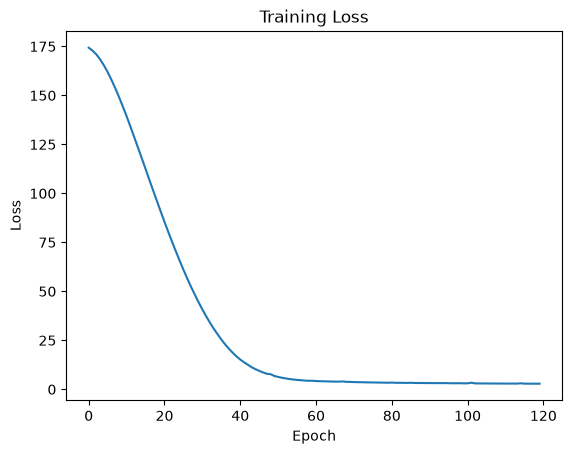

In [54]:
plt.plot(loss_history)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.show()

In [62]:
def get_reconstruction_errors(model, data_loader):
    model.eval()
    errors = []

    with torch.no_grad():
        for (features,) in data_loader:
            features = features.to(device)
            reconstructed = model(features)
            sample_errors = torch.mean((reconstructed - features) ** 2, dim=1)
            errors.extend(sample_errors.cpu().numpy())

    return np.asarray(errors)


# 정상 학습 데이터의 재구성 오차를 기준으로 이상치 임계값 설정
train_errors = get_reconstruction_errors(autoencoder, train_loader)
threshold = np.percentile(train_errors, 99.667)

# 훈련 데이터 중 이상치만 추출
anomaly_train_mask = train_errors > threshold
anomaly_train_data = train_scaled.loc[anomaly_train_mask].copy()
anomaly_train_data['reconstruction_error'] = train_errors[anomaly_train_mask]

print(f'Threshold: {threshold:.6f}')
print(f'Anomaly count: {len(anomaly_train_data)} / {len(train_scaled)}')


# 이상치 데이터만 K-Means 군집화 
anomaly_train_features = anomaly_train_data.drop(columns='reconstruction_error')

gmm = GaussianMixture(n_components=3)
anomaly_train_data['cluster'] = gmm.fit_predict(anomaly_train_features)


Threshold: 247.789978
Anomaly count: 27 / 8470


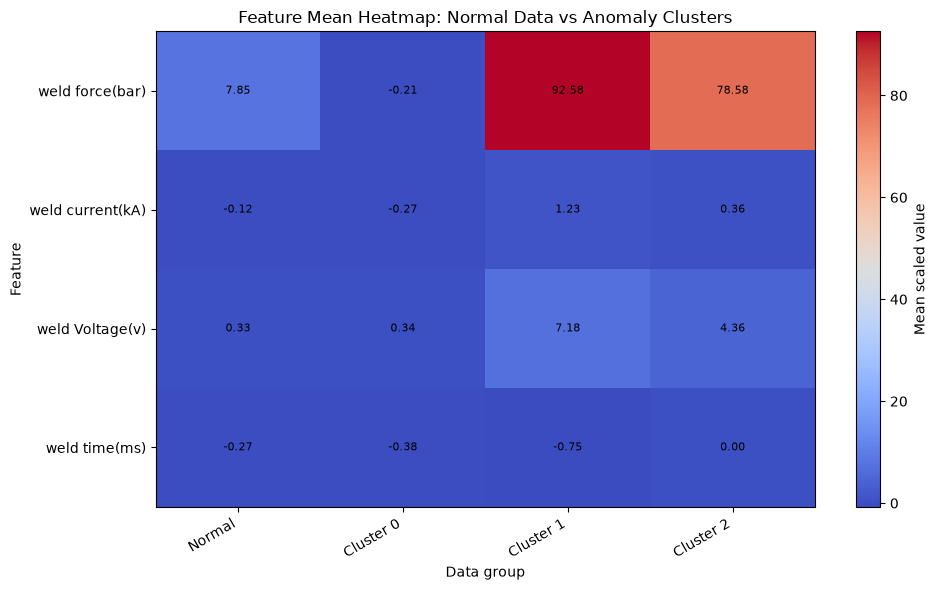

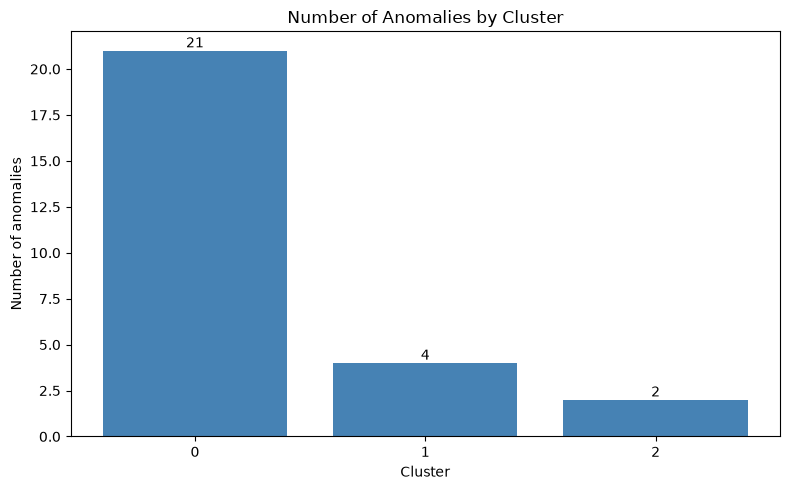

In [63]:
# anomaly_data 시각화

if len(anomaly_train_data) > 0:
    feature_columns = train_scaled.columns

    # 정상 데이터와 군집별 이상치 데이터 분리
    normal_data = train_scaled.loc[~anomaly_train_mask, feature_columns]
    heatmap_data = {'Normal': normal_data.mean()}

    if 'cluster' in anomaly_train_data.columns:
        for cluster_id in sorted(anomaly_train_data['cluster'].unique()):
            cluster_data = anomaly_train_data.loc[
                anomaly_train_data['cluster'] == cluster_id,
                feature_columns
            ]
            heatmap_data[f'Cluster {cluster_id}'] = cluster_data.mean()

    # 행: feature, 열: 정상 데이터 및 각 군집, 값: feature 평균
    heatmap_data = pd.DataFrame(heatmap_data, index=feature_columns)

    plt.figure(figsize=(10, max(6, len(feature_columns) * 0.35)))
    image = plt.imshow(heatmap_data, cmap='coolwarm', aspect='auto')
    plt.colorbar(image, label='Mean scaled value')
    plt.xticks(
        range(len(heatmap_data.columns)),
        heatmap_data.columns,
        rotation=30,
        ha='right'
    )
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.xlabel('Data group')
    plt.ylabel('Feature')
    plt.title('Feature Mean Heatmap: Normal Data vs Anomaly Clusters')

    # feature 수가 많지 않을 때만 셀에 평균값 표시
    if heatmap_data.size <= 150:
        for row_index in range(len(heatmap_data.index)):
            for column_index in range(len(heatmap_data.columns)):
                value = heatmap_data.iloc[row_index, column_index]
                plt.text(
                    column_index,
                    row_index,
                    f'{value:.2f}',
                    ha='center',
                    va='center',
                    fontsize=8
                )

    plt.tight_layout()
    plt.show()

    # 군집별 이상치 개수 bar chart
    if 'cluster' in anomaly_train_data.columns:
        cluster_counts = anomaly_train_data['cluster'].value_counts().sort_index()

        plt.figure(figsize=(8, 5))
        bars = plt.bar(
            cluster_counts.index.astype(str),
            cluster_counts.values,
            color='steelblue'
        )
        plt.xlabel('Cluster')
        plt.ylabel('Number of anomalies')
        plt.title('Number of Anomalies by Cluster')

        for bar in bars:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{int(bar.get_height())}',
                ha='center',
                va='bottom'
            )

        plt.tight_layout()
        plt.show()


In [64]:
# 테스트 데이터 성능 확인

test_loss = evaluate(autoencoder, test_loader, criterion)
print(f'Test loss : {test_loss}')

# 테스트 데이터 중 이상치만 추출
test_errors = get_reconstruction_errors(autoencoder, test_loader)
anomaly_test_mask = test_errors > threshold
anomaly_test_data = test_scaled.loc[anomaly_test_mask].copy()
anomaly_test_data['reconstruction_error'] = test_errors[anomaly_test_mask]

print(f'Threshold: {threshold:.6f}')
print(f'Anomaly count: {len(anomaly_test_data)} / {len(test_scaled)}')


# 이상치 데이터만 K-Means 군집화 
anomaly_test_features = anomaly_test_data.drop(columns='reconstruction_error')

anomaly_test_data['cluster'] = gmm.predict(anomaly_test_features)

Test loss : 2.3589242978032776
Threshold: 247.789978
Anomaly count: 9 / 3469


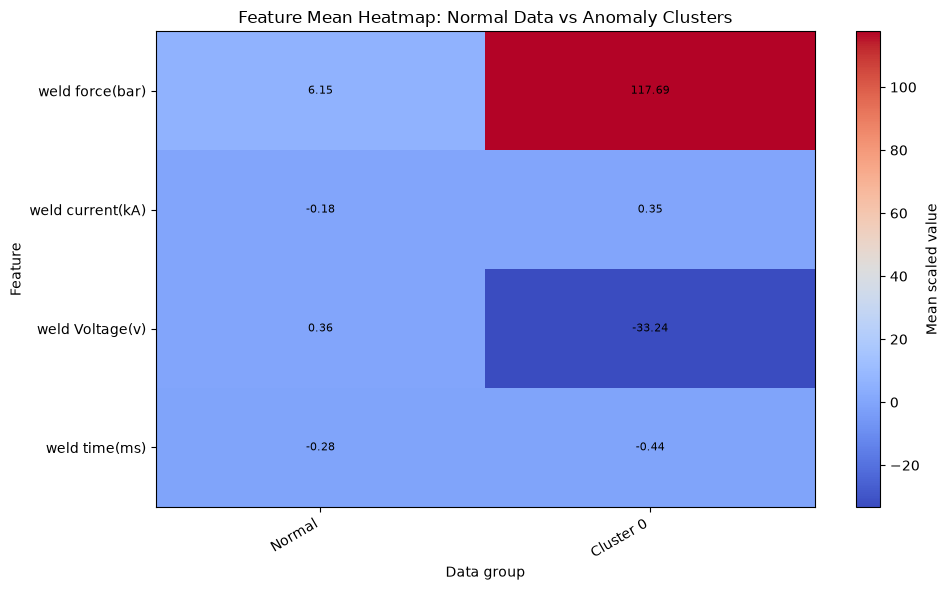

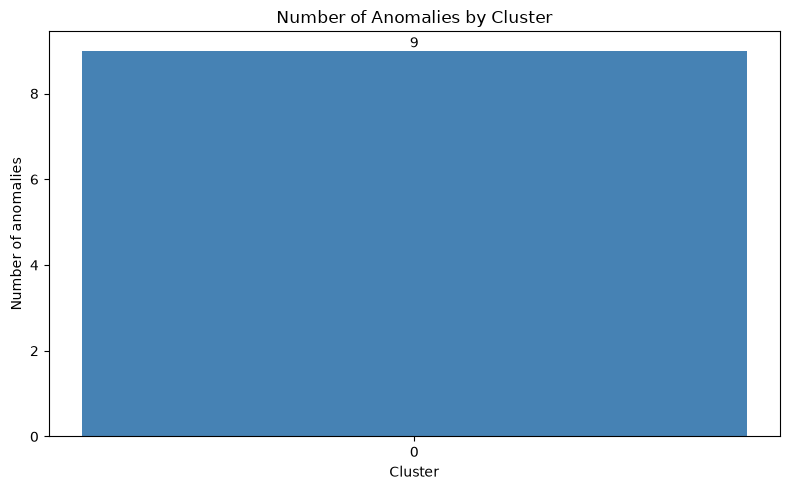

In [65]:
# anomaly_data 시각화

if len(anomaly_test_data) > 0:
    feature_columns = test_scaled.columns

    # 정상 데이터와 군집별 이상치 데이터 분리
    normal_data = test_scaled.loc[~anomaly_test_mask, feature_columns]
    heatmap_data = {'Normal': normal_data.mean()}

    if 'cluster' in anomaly_test_data.columns:
        for cluster_id in sorted(anomaly_test_data['cluster'].unique()):
            cluster_data = anomaly_test_data.loc[
                anomaly_test_data['cluster'] == cluster_id,
                feature_columns
            ]
            heatmap_data[f'Cluster {cluster_id}'] = cluster_data.mean()

    # 행: feature, 열: 정상 데이터 및 각 군집, 값: feature 평균
    heatmap_data = pd.DataFrame(heatmap_data, index=feature_columns)

    plt.figure(figsize=(10, max(6, len(feature_columns) * 0.35)))
    image = plt.imshow(heatmap_data, cmap='coolwarm', aspect='auto')
    plt.colorbar(image, label='Mean scaled value')
    plt.xticks(
        range(len(heatmap_data.columns)),
        heatmap_data.columns,
        rotation=30,
        ha='right'
    )
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.xlabel('Data group')
    plt.ylabel('Feature')
    plt.title('Feature Mean Heatmap: Normal Data vs Anomaly Clusters')

    # feature 수가 많지 않을 때만 셀에 평균값 표시
    if heatmap_data.size <= 150:
        for row_index in range(len(heatmap_data.index)):
            for column_index in range(len(heatmap_data.columns)):
                value = heatmap_data.iloc[row_index, column_index]
                plt.text(
                    column_index,
                    row_index,
                    f'{value:.2f}',
                    ha='center',
                    va='center',
                    fontsize=8
                )

    plt.tight_layout()
    plt.show()

    # 군집별 이상치 개수 bar chart
    if 'cluster' in anomaly_test_data.columns:
        cluster_counts = anomaly_test_data['cluster'].value_counts().sort_index()

        plt.figure(figsize=(8, 5))
        bars = plt.bar(
            cluster_counts.index.astype(str),
            cluster_counts.values,
            color='steelblue'
        )
        plt.xlabel('Cluster')
        plt.ylabel('Number of anomalies')
        plt.title('Number of Anomalies by Cluster')

        for bar in bars:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{int(bar.get_height())}',
                ha='center',
                va='bottom'
            )

        plt.tight_layout()
        plt.show()
